## **Multi-Channel E-commerce with Behavioral Metrics**

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

##### Step 0: Read the File

In [ ]:
# Read the customer.csv file into a dataframe
file_id = '1yPNAtQ4HxHaVpUZg7dU3mBCcGwgpnVLe'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)
display(df)

,CustomerID,Customer_Segment,Acquisition_Date,Age,Gender,Job_Category,Annual_Income,Education_Level,Marital_Status,Household_Size,...,Profitability_Score,Age_Group,Revenue_Tier,Seasonal_Factor,Purchase_Month,Purchase_Quarter,Purchase_Year,Days_Since_Acquisition,Acquisition_Month,Cohort_Index
0,C00001,Regular,2023-12-05,49,Female,Manufacturing,53900,Bachelor,Single,2,...,2.04,46-60,Low,1.4,10,4,2024,316,2023-12,10
1,C00002,New,2023-01-26,39,Male,IT,47557,High School,Single,2,...,0.06,31-45,Low,0.9,4,2,2023,89,2023-01,3
2,C00003,Regular,2023-07-01,51,Female,Other,81597,High School,Widowed,2,...,0.66,46-60,Low,0.9,1,1,2023,-156,2023-07,-6
3,C00004,Regular,2023-09-22,64,Male,Finance,100299,Bachelor,Married,3,...,53.40,60+,Premium,1.4,10,4,2023,17,2023-09,1
4,C00005,New,2023-09-15,38,Female,Other,132438,Master,Married,2,...,7.24,31-45,High,1.4,9,3,2023,-7,2023-09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,Regular,2023-03-05,42,Male,Healthcare,25000,Bachelor,Married,3,...,8.39,31-45,Medium,1.4,7,3,2024,499,2023-03,16
49996,C49997,VIP,2023-04-26,41,Male,Manufacturing,36221,High School,Married,1,...,15.65,31-45,Premium,1.4,10,4,2024,554,2023-04,18
49997,C49998,New,2023-11-23,49,Male,Education,41384,Bachelor,Divorced,2,...,11.31,46-60,High,1.4,6,2,2024,219,2023-11,7
49998,C49999,New,2023-12-01,45,Male,IT,25344,Bachelor,Married,2,...,1.37,31-45,Low,1.1,5,2,2024,173,2023-12,5



---



#### ETL Process



---


##### Step 1: Drop Unwanted Variables

In [ ]:
# Keeping desired columns
cols_to_keep = [
    'Customer_Segment', 'Annual_Income', 'Household_Size', 'Product',
    'Quantity', 'Unit_Price', 'Discount_Applied', 'Payment_Method',
    'Loyalty_Score', 'Loyalty_Tier', 'Customer_Satisfaction',
    'Purchase_Frequency', 'Days_Since_Last_Purchase', 'Newsletter_Subscribed',
    'Support_Tickets', 'Email_Open_Rate', 'Social_Media_Engagement',
    'Purchase_Hour', 'Days_to_Next_Purchase', 'Return_Rate',
    'Payment_Delay_Days', 'First_Purchase_Channel', 'Days_Since_Acquisition',
    'Churned'
]

df = df[cols_to_keep].copy()
print("Working shape:", df.shape)
df.head()

Working shape: (50000, 24)


,Customer_Segment,Annual_Income,Household_Size,Product,Quantity,Unit_Price,Discount_Applied,Payment_Method,Loyalty_Score,Loyalty_Tier,...,Support_Tickets,Email_Open_Rate,Social_Media_Engagement,Purchase_Hour,Days_to_Next_Purchase,Return_Rate,Payment_Delay_Days,First_Purchase_Channel,Days_Since_Acquisition,Churned
0,Regular,53900,2,Product_C,2,40.56,0.449,Bank Transfer,7.7,Bronze,...,0,0.072,0.187,19,58,0.014,8,Online,316,1
1,New,47557,2,Product_D,3,79.07,0.187,PayPal,12.1,Bronze,...,0,0.246,0.033,14,24,0.012,3,App,89,1
2,Regular,81597,2,Product_E,3,36.91,0.071,Credit Card,16.3,Bronze,...,1,0.141,0.319,14,26,0.034,1,Online,-156,1
3,Regular,100299,3,Product_D,1,85.07,0.344,PayPal,40.3,Silver,...,1,0.585,0.062,16,5,0.014,26,App,17,0
4,New,132438,2,Product_E,1,64.41,0.283,Bank Transfer,29.7,Silver,...,0,0.165,0.048,12,7,0.007,2,Online,-7,1


##### Step 2: Check the Data Type

In [ ]:
# object = text/categorical, int64 = whole number, float64 = decimal
print(df.dtypes)
print("---")
print(f"Total columns: {df.shape[1]}")
print(f"Total rows:    {df.shape[0]}")

Customer_Segment             object
Annual_Income                 int64
Household_Size                int64
Product                      object
Quantity                      int64
Unit_Price                  float64
Discount_Applied            float64
Payment_Method               object
Loyalty_Score               float64
Loyalty_Tier                 object
Customer_Satisfaction       float64
Purchase_Frequency            int64
Days_Since_Last_Purchase      int64
Newsletter_Subscribed         int64
Support_Tickets               int64
Email_Open_Rate             float64
Social_Media_Engagement     float64
Purchase_Hour                 int64
Days_to_Next_Purchase         int64
Return_Rate                 float64
Payment_Delay_Days            int64
First_Purchase_Channel       object
Days_Since_Acquisition        int64
Churned                       int64
dtype: object
---
Total columns: 24
Total rows:    50000


Looks clean. Everything is exactly what we'd expect. Churned is int64 (0 or 1). It's perfect for logistic regression.
Quick summary of what we have:

9 categorical (str) columns → will need encoding later
9 integer (int64) columns → ready to use
4 decimal (float64) columns → ready to use
Acquisition_Month is str as 2023-12 format → we'll extract just the month number later

##### Step 3: Check for Missing Values

In [ ]:
# Check the dataset for missing values
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct'  : (df.isnull().sum() / len(df) * 100).round(2)
})

missing_only = missing[missing['missing_count'] > 0]

if missing_only.empty:
    print("No missing values found across all 23 columns.")
else:
    print(f"{len(missing_only)} column(s) have missing values:\n")
    print(missing_only)

No missing values found across all 23 columns.


Step 4: Encode the columns

In [ ]:
# Ordinal encode for Loyalty_tier
tier_order = [['Bronze', 'Silver', 'Gold', 'Platinum']]
df['Loyalty_Tier'] = OrdinalEncoder(categories=tier_order).fit_transform(df[['Loyalty_Tier']])

In [ ]:
# One-hot encoding for the unordered categorical columns
cat_cols = ['Customer_Segment', 'Product', 'Payment_Method', 'First_Purchase_Channel']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df.shape)

Shape after encoding: (50000, 32)



---



#### Logistic Regression


---


##### Step 5: Test and Train the Data

In [ ]:
# Split
X = df.drop(columns='Churned')
y = df['Churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scale (fit on train only)
num_cols = [
    'Annual_Income', 'Household_Size', 'Quantity', 'Unit_Price',
    'Discount_Applied', 'Loyalty_Score', 'Customer_Satisfaction',
    'Purchase_Frequency', 'Days_Since_Last_Purchase', 'Newsletter_Subscribed',
    'Support_Tickets', 'Email_Open_Rate', 'Social_Media_Engagement',
    'Purchase_Hour', 'Days_to_Next_Purchase', 'Return_Rate',
    'Payment_Delay_Days', 'Days_Since_Acquisition'
]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [ ]:
# Train & evaluate
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0       0.43      0.67      0.52      2343
           1       0.88      0.73      0.80      7657

    accuracy                           0.71     10000
   macro avg       0.65      0.70      0.66     10000
weighted avg       0.77      0.71      0.73     10000

AUC-ROC: 0.766


The extracted coefficients are assigned to each feature and ranked by their absolute value. This tells us which features had the most influence on the model's churn predictions, regardless of whether they increased or decreased the likelihood of churn. Features with larger absolute coefficeints had a stronger imoact on the model's decision, while features closer to zero had little to no influence.

###### Step 6: Confusion Matrix

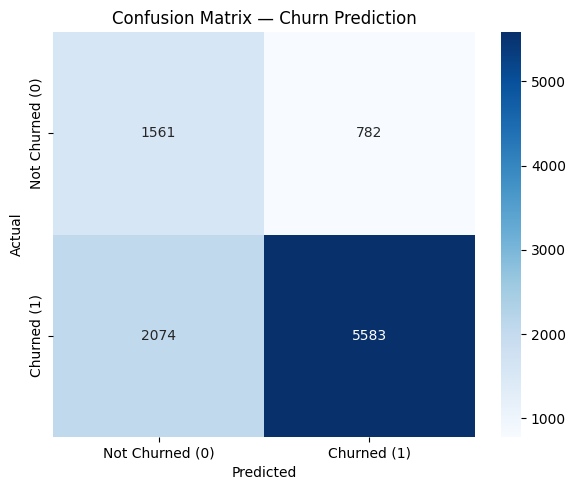

True Negatives  (predicted stay,  actually stay):  1561
False Positives (predicted churn, actually stay):  782
False Negatives (predicted stay,  actually churn): 2074
True Positives  (predicted churn, actually churn): 5583


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Churned (0)', 'Churned (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Churn Prediction')
plt.tight_layout()
plt.show()

# Print readable breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (predicted stay,  actually stay):  {tn}")
print(f"False Positives (predicted churn, actually stay):  {fp}")
print(f"False Negatives (predicted stay,  actually churn): {fn}")
print(f"True Positives  (predicted churn, actually churn): {tp}")

Confusion Matrix Interpretation:


This confusion matrix shows how our model performed on 10,000 test customers.
The first thing you notice visually is the color contrast one box is dark navy, the others are light blue. That contrast is telling us something important about how the model behaves.

The dark box 5,583 represents customers the model correctly predicted would churn. That's the model at its strongest. Combined with the 1,561 true negatives, the model is doing solid work overall.
But look at the light boxes. 2,074 customers actually churned and the model missed them it thought they'd stay. And 782 customers the model flagged as churners actually stayed.

This visual pattern tells us clearly: the model is much better at predicting churn than predicting loyalty. When it says a customer will leave, it's right 88% of the time. But when it says a customer will stay, it's less confident — only 43% precision.

Why? Because the dataset has roughly 3x more churners than non-churners, so the model learned to recognize churn patterns very well, but had fewer examples of loyal customers to learn from.

The takeaway for a business: trust this model's churn alerts  when it flags someone as at risk, act on it.

##### Step 7: Feature Importance

In [ ]:
# Feature Importance
# Create the base dataframe
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

# Get the absolute values
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort the values from most influential to least
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print(coef_df)


                          Feature  Coefficient  Abs_Coefficient
5                   Loyalty_Score    -1.113144         1.113144
20           Customer_Segment_VIP    -0.098686         0.098686
24              Product_Product_E    -0.072973         0.072973
19       Customer_Segment_Regular    -0.062669         0.062669
26  Payment_Method_Digital Wallet     0.055236         0.055236
30   First_Purchase_Channel_Store     0.046305         0.046305
29   First_Purchase_Channel_Phone     0.045121         0.045121
28  First_Purchase_Channel_Online     0.044740         0.044740
7           Customer_Satisfaction     0.041586         0.041586
22              Product_Product_C    -0.030054         0.030054
11                Support_Tickets     0.018837         0.018837
1                  Household_Size     0.016265         0.016265
27          Payment_Method_PayPal     0.014538         0.014538
12                Email_Open_Rate    -0.012542         0.012542
25     Payment_Method_Credit Card     0.